In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

data = pd.read_csv("dynamic_pricing.csv")
print("Data Loaded")
print(f"Shape: {data.shape}")
data.head()

Data Loaded
Shape: (1000, 10)


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [39]:

print("DATASET INFO")

data.info()
print("\nColumns:", list(data.columns))

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB

Columns: ['Number_of_Riders', 'Number_of_Drivers', 'Location_Category', 'Customer_Loyalty_Status', 'Number_of_Past_Rides', 'Average_Ratings', 'Time_of_Booking', 'Vehicle

In [40]:
print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
print(data.isnull().sum())

print("\n" + "=" * 60)
print("DUPLICATES")
print("=" * 60)
dup_count = data.duplicated().sum()
print(f"Duplicate rows: {dup_count}")

if dup_count > 0:
    data = data.drop_duplicates()
    print(f" Removed. New shape: {data.shape}")
else:
    print(" No duplicates found")

MISSING VALUES
Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
dtype: int64

DUPLICATES
Duplicate rows: 0
 No duplicates found


In [41]:
print("=" * 60)
print("NUMERICAL SUMMARY")
print("=" * 60)
print(data.describe().round(2))

print("\n" + "=" * 60)
print("CATEGORICAL SUMMARY")
print("=" * 60)
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}:\n{data[col].value_counts()}")

NUMERICAL SUMMARY
       Number_of_Riders  Number_of_Drivers  Number_of_Past_Rides  \
count           1000.00            1000.00               1000.00   
mean              60.37              27.08                 50.03   
std               23.70              19.07                 29.31   
min               20.00               5.00                  0.00   
25%               40.00              11.00                 25.00   
50%               60.00              22.00                 51.00   
75%               81.00              38.00                 75.00   
max              100.00              89.00                100.00   

       Average_Ratings  Expected_Ride_Duration  Historical_Cost_of_Ride  
count          1000.00                 1000.00                  1000.00  
mean              4.26                   99.59                   372.50  
std               0.44                   49.17                   187.16  
min               3.50                   10.00                    25.99  

OUTLIER DETECTION (IQR METHOD)
Number_of_Riders               | Outliers: 0
Number_of_Drivers              | Outliers: 10
Number_of_Past_Rides           | Outliers: 0
Average_Ratings                | Outliers: 0
Expected_Ride_Duration         | Outliers: 0
Historical_Cost_of_Ride        | Outliers: 0


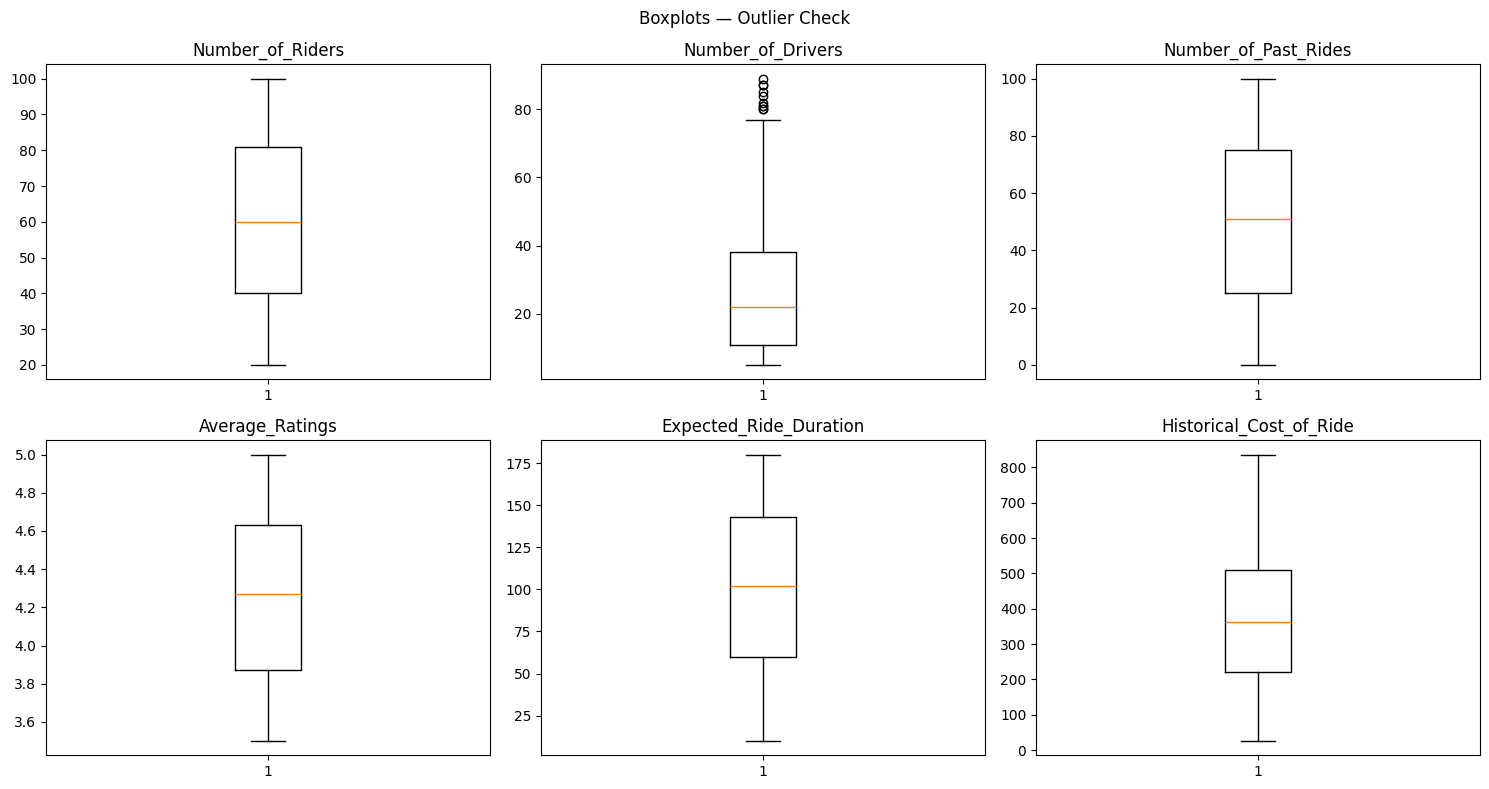

In [42]:
print("=" * 60)
print("OUTLIER DETECTION (IQR METHOD)")
print("=" * 60)

num_cols = data.select_dtypes(include=np.number).columns
for col in num_cols:
    Q1, Q3 = data[col].quantile(0.25), data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    print(f"{col:30s} | Outliers: {len(outliers)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:6]):
    axes[i].boxplot(data[col].dropna())
    axes[i].set_title(col)
plt.suptitle("Boxplots — Outlier Check")
plt.tight_layout()
plt.show()

DISTRIBUTIONS — NUMERICAL


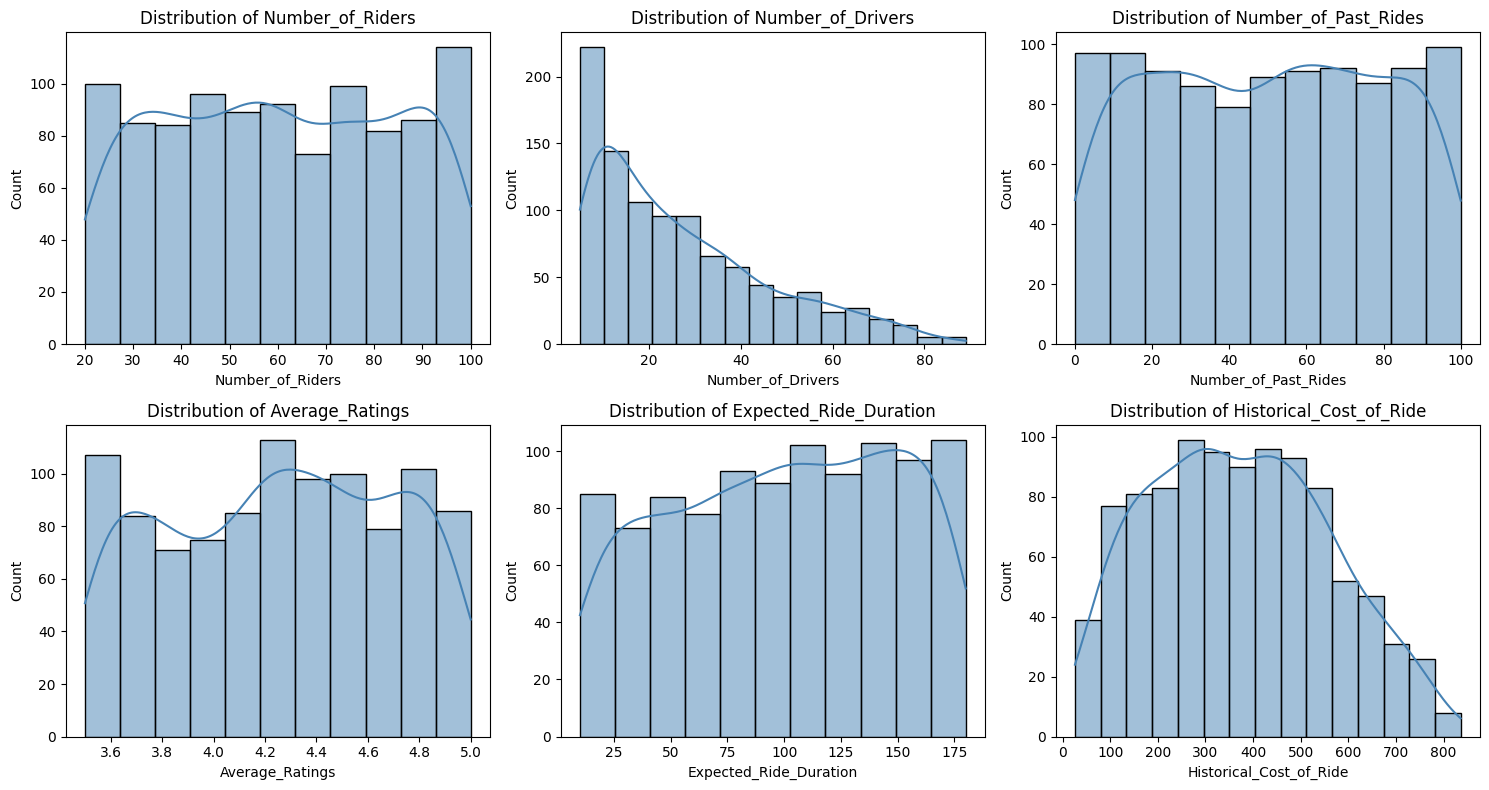

DISTRIBUTIONS — CATEGORICAL


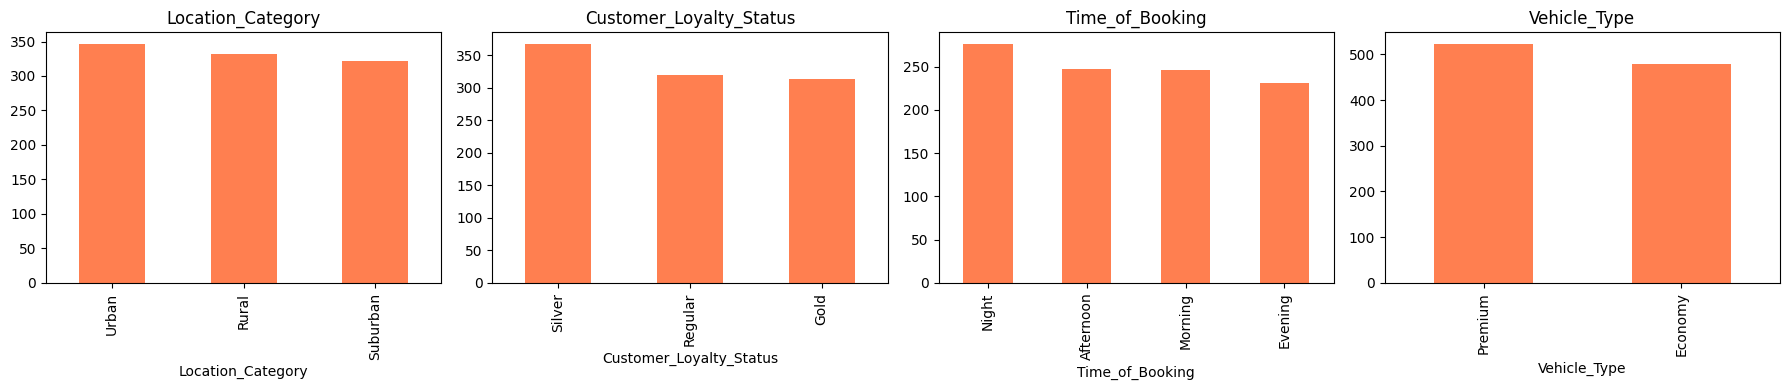

In [43]:
print("=" * 60)
print("DISTRIBUTIONS — NUMERICAL")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols[:6]):
    sns.histplot(data[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

print("=" * 60)
print("DISTRIBUTIONS — CATEGORICAL")
print("=" * 60)

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))
for i, col in enumerate(cat_cols):
    data[col].value_counts().plot(kind='bar', ax=axes[i], color='coral')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

CORRELATION WITH Historical_Cost_of_Ride (Raw Variables)
Historical_Cost_of_Ride    1.000000
Expected_Ride_Duration     0.927547
Number_of_Past_Rides       0.035859
Number_of_Drivers          0.017082
Number_of_Riders           0.005826
Average_Ratings           -0.001063
Name: Historical_Cost_of_Ride, dtype: float64


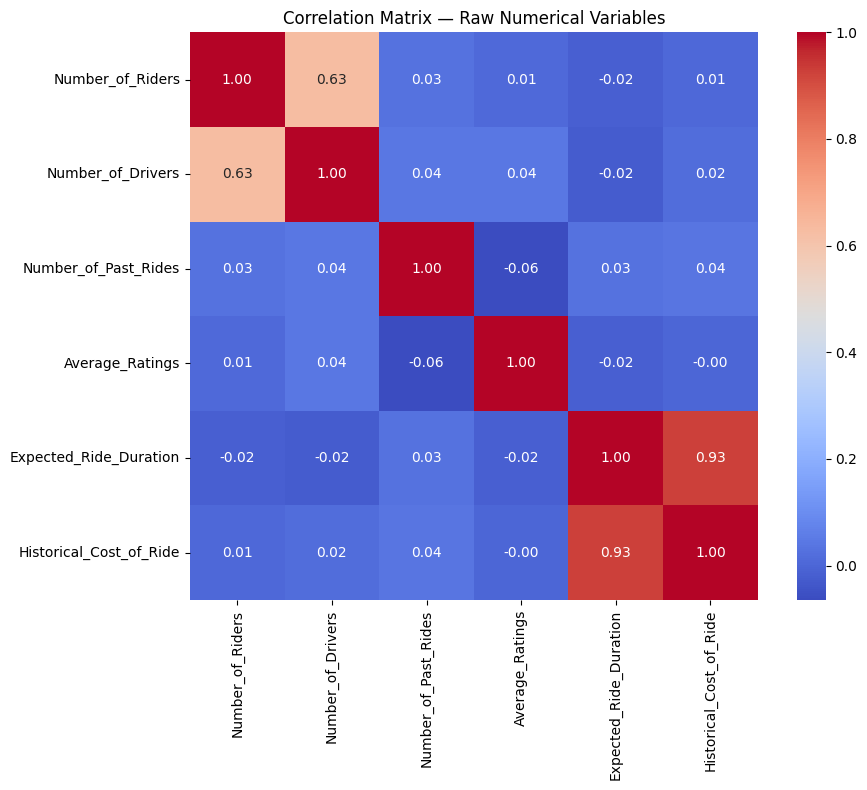

In [44]:
print("=" * 60)
print("CORRELATION WITH Historical_Cost_of_Ride (Raw Variables)")
print("=" * 60)

corr_target = data[num_cols].corr()['Historical_Cost_of_Ride'].sort_values(ascending=False)
print(corr_target)

plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title("Correlation Matrix — Raw Numerical Variables")
plt.tight_layout()
plt.show()

Historical_Cost_of_Ride BY CATEGORY


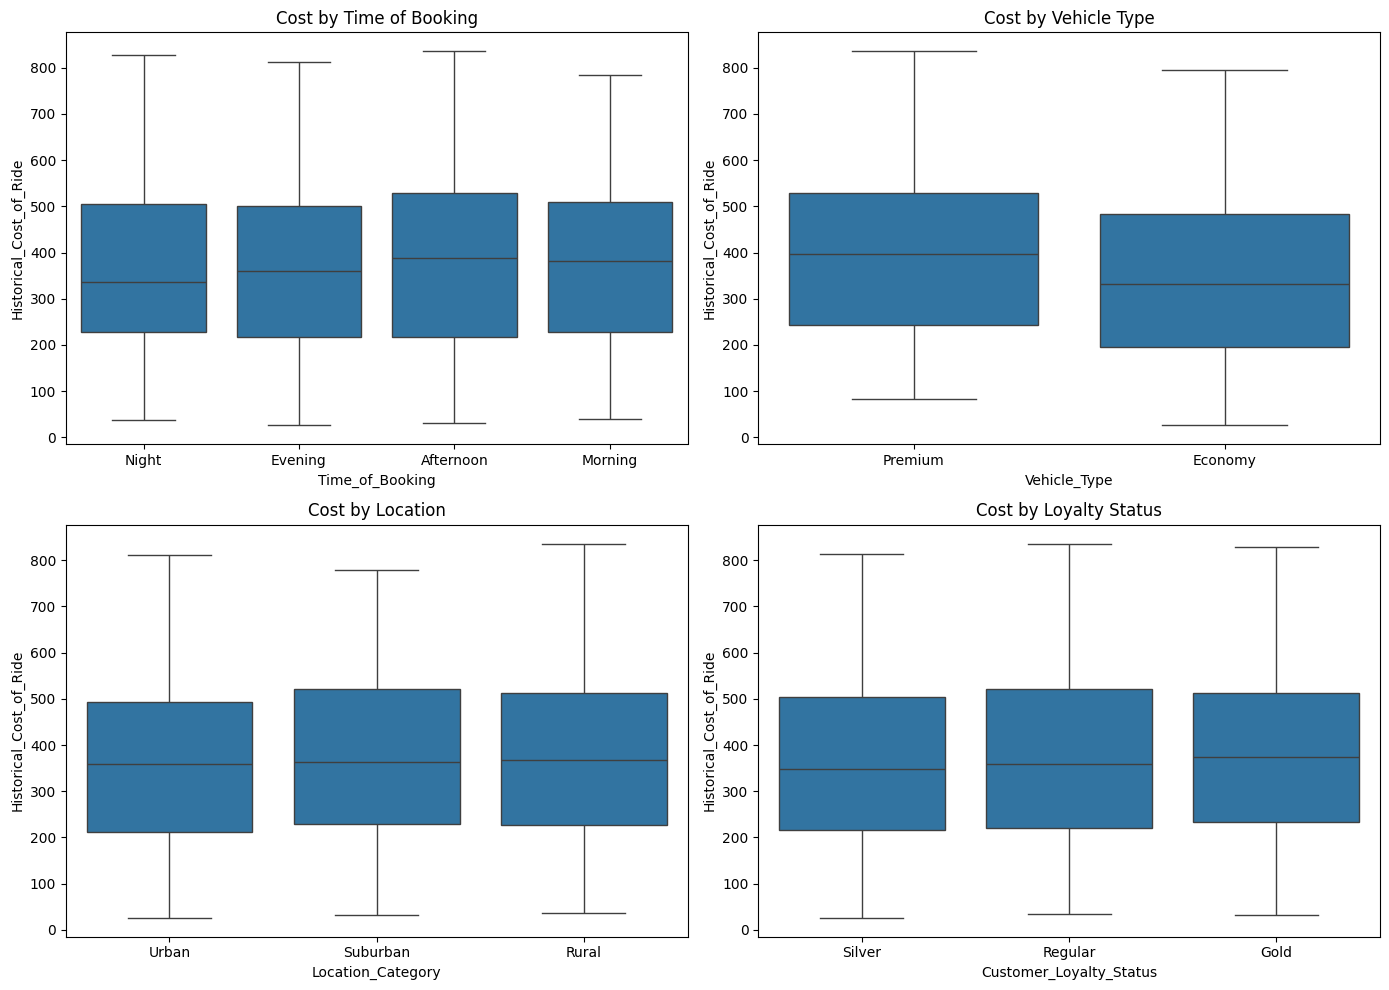


Mean cost by Time_of_Booking:
Time_of_Booking
Afternoon    380.82
Morning      378.06
Night        367.01
Evening      364.25
Name: Historical_Cost_of_Ride, dtype: float64

Mean cost by Vehicle_Type:
Vehicle_Type
Premium    396.25
Economy    346.57
Name: Historical_Cost_of_Ride, dtype: float64

Mean cost by Location_Category:
Location_Category
Rural       379.94
Suburban    374.32
Urban       363.67
Name: Historical_Cost_of_Ride, dtype: float64

Mean cost by Customer_Loyalty_Status:
Customer_Loyalty_Status
Regular    380.13
Gold       376.12
Silver     362.77
Name: Historical_Cost_of_Ride, dtype: float64


In [45]:
print("=" * 60)
print("Historical_Cost_of_Ride BY CATEGORY")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=data, x='Time_of_Booking', y='Historical_Cost_of_Ride', ax=axes[0,0])
axes[0,0].set_title('Cost by Time of Booking')

sns.boxplot(data=data, x='Vehicle_Type', y='Historical_Cost_of_Ride', ax=axes[0,1])
axes[0,1].set_title('Cost by Vehicle Type')

sns.boxplot(data=data, x='Location_Category', y='Historical_Cost_of_Ride', ax=axes[1,0])
axes[1,0].set_title('Cost by Location')

sns.boxplot(data=data, x='Customer_Loyalty_Status', y='Historical_Cost_of_Ride', ax=axes[1,1])
axes[1,1].set_title('Cost by Loyalty Status')

plt.tight_layout()
plt.show()

# Print group means for clarity
for col in ['Time_of_Booking','Vehicle_Type','Location_Category','Customer_Loyalty_Status']:
    print(f"\nMean cost by {col}:")
    print(data.groupby(col)['Historical_Cost_of_Ride'].mean().sort_values(ascending=False).round(2))

RIDER-DRIVER RATIO vs SEPARATE COUNTS — WHICH EXPLAINS COST BETTER?

Correlation with Historical_Cost_of_Ride:
Number_of_Riders           0.0058
Number_of_Drivers          0.0171
rider_driver_ratio        -0.0944
Historical_Cost_of_Ride    1.0000
Name: Historical_Cost_of_Ride, dtype: float64


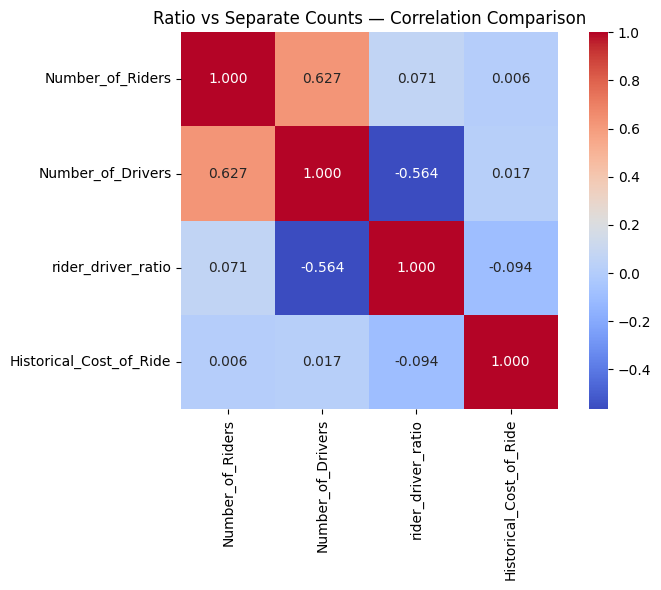

In [46]:
print("=" * 60)
print("RIDER-DRIVER RATIO vs SEPARATE COUNTS — WHICH EXPLAINS COST BETTER?")
print("=" * 60)

data['rider_driver_ratio'] = data['Number_of_Riders'] / data['Number_of_Drivers']

comparison_cols = ['Number_of_Riders', 'Number_of_Drivers', 'rider_driver_ratio',
                    'Historical_Cost_of_Ride']

corr_comparison = data[comparison_cols].corr()['Historical_Cost_of_Ride']
print("\nCorrelation with Historical_Cost_of_Ride:")
print(corr_comparison.round(4))

plt.figure(figsize=(8, 6))
sns.heatmap(data[comparison_cols].corr(), annot=True, fmt='.3f', cmap='coolwarm', square=True)
plt.title("Ratio vs Separate Counts — Correlation Comparison")
plt.tight_layout()
plt.show()

SCATTER PLOTS — VISUAL RELATIONSHIP CHECK


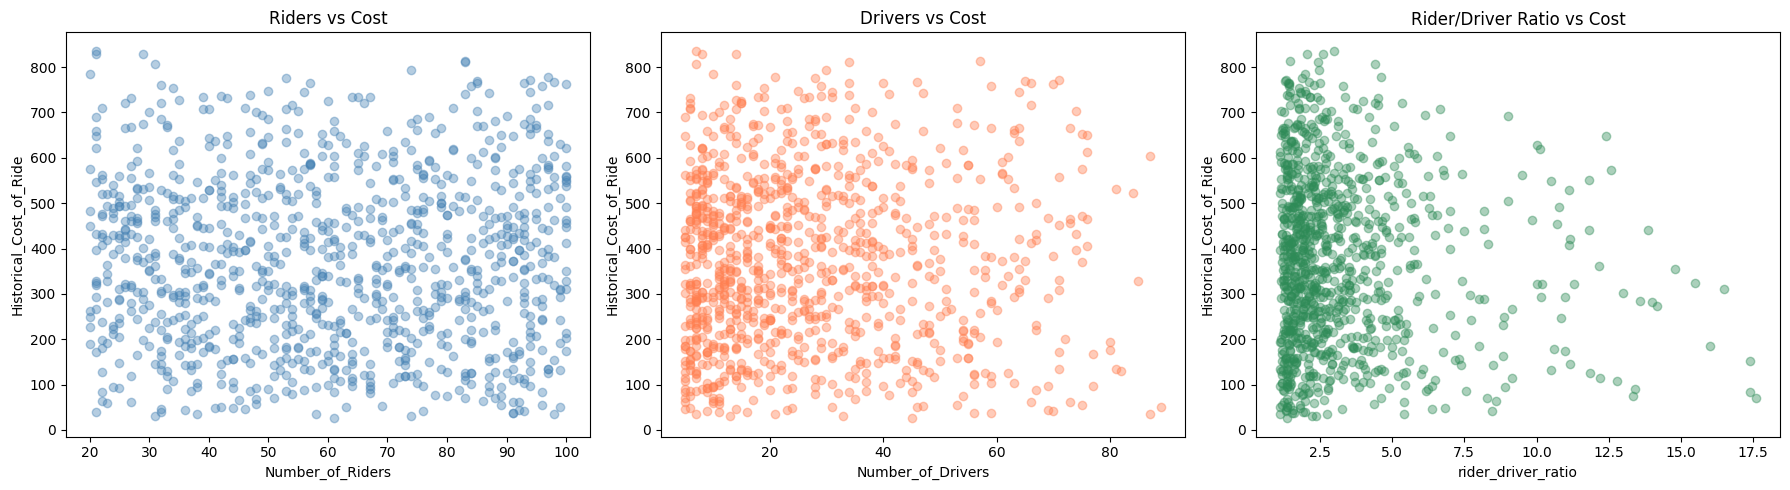

In [47]:
print("=" * 60)
print("SCATTER PLOTS — VISUAL RELATIONSHIP CHECK")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(data['Number_of_Riders'], data['Historical_Cost_of_Ride'], alpha=0.4, color='steelblue')
axes[0].set_xlabel('Number_of_Riders')
axes[0].set_ylabel('Historical_Cost_of_Ride')
axes[0].set_title('Riders vs Cost')

axes[1].scatter(data['Number_of_Drivers'], data['Historical_Cost_of_Ride'], alpha=0.4, color='coral')
axes[1].set_xlabel('Number_of_Drivers')
axes[1].set_ylabel('Historical_Cost_of_Ride')
axes[1].set_title('Drivers vs Cost')

axes[2].scatter(data['rider_driver_ratio'], data['Historical_Cost_of_Ride'], alpha=0.4, color='seagreen')
axes[2].set_xlabel('rider_driver_ratio')
axes[2].set_ylabel('Historical_Cost_of_Ride')
axes[2].set_title('Rider/Driver Ratio vs Cost')

plt.tight_layout()
plt.show()

BINNED ANALYSIS — RATIO QUARTILES vs AVG COST
                  mean  median  count
ratio_quartile                       
Q1 (Low)        360.16  347.58    250
Q2              391.81  383.91    251
Q3              389.93  380.48    250
Q4 (High)       347.93  328.31    249


C:\Users\umasu\AppData\Local\Temp\ipykernel_38332\661651649.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_analysis = data.groupby('ratio_quartile')['Historical_Cost_of_Ride'].agg(['mean', 'median', 'count'])
C:\Users\umasu\AppData\Local\Temp\ipykernel_38332\661651649.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby('ratio_quartile')['Historical_Cost_of_Ride'].mean().plot(


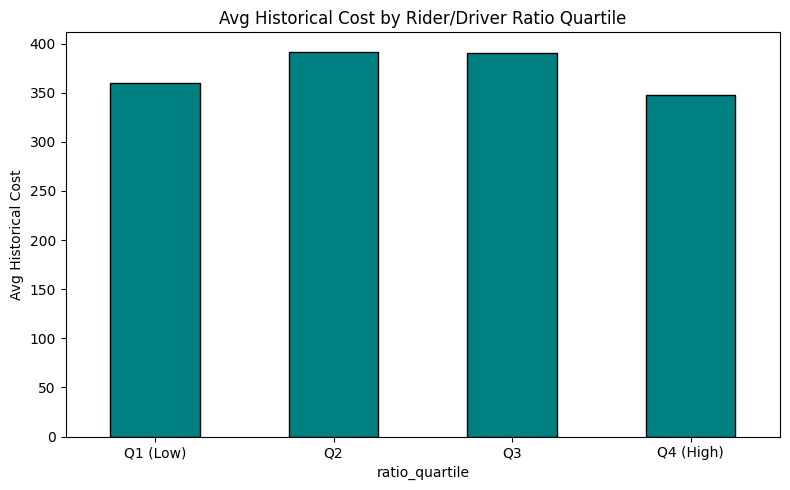

In [48]:
print("=" * 60)
print("BINNED ANALYSIS — RATIO QUARTILES vs AVG COST")
print("=" * 60)

data['ratio_quartile'] = pd.qcut(data['rider_driver_ratio'], q=4, 
                                   labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'])

ratio_analysis = data.groupby('ratio_quartile')['Historical_Cost_of_Ride'].agg(['mean', 'median', 'count'])
print(ratio_analysis.round(2))

plt.figure(figsize=(8, 5))
data.groupby('ratio_quartile')['Historical_Cost_of_Ride'].mean().plot(
    kind='bar', color='teal', edgecolor='black')
plt.title("Avg Historical Cost by Rider/Driver Ratio Quartile")
plt.ylabel("Avg Historical Cost")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [49]:
print("=" * 60)
print("DECISION SUMMARY")
print("=" * 60)

summary = pd.DataFrame({
    'Variable': ['Number_of_Riders', 'Number_of_Drivers', 'rider_driver_ratio'],
    'Correlation_with_Cost': [
        corr_comparison['Number_of_Riders'],
        corr_comparison['Number_of_Drivers'],
        corr_comparison['rider_driver_ratio']
    ]
}).round(4)


DECISION SUMMARY


TRIP DISTANCE RELATIONSHIP CHECK
       Expected_Ride_Duration  Historical_Cost_of_Ride
count              1000.00000              1000.000000
mean                 99.58800               372.502623
std                  49.16545               187.158756
min                  10.00000                25.993449
25%                  59.75000               221.365202
50%                 102.00000               362.019426
75%                 143.00000               510.497504
max                 180.00000               836.116419


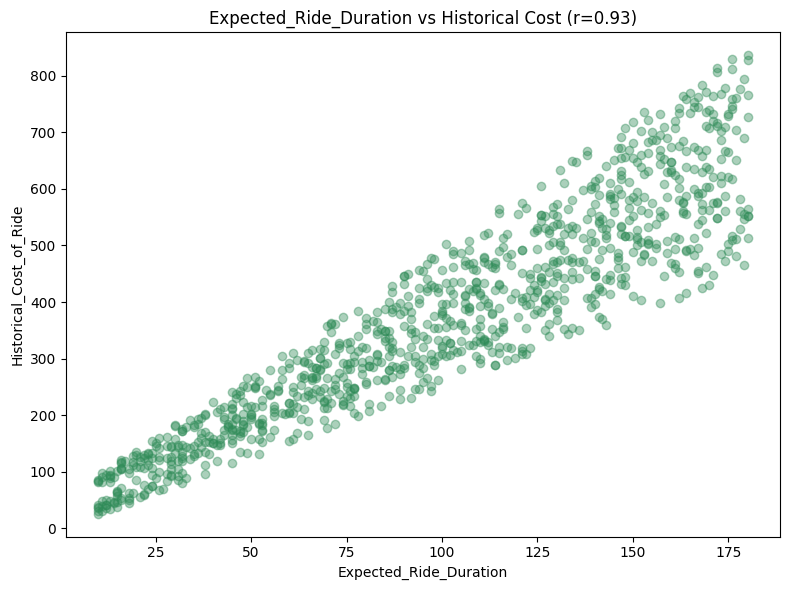


Implied rate per distance unit:
count    1000.000
mean        3.890
std         0.913
min         2.503
25%         3.244
50%         3.772
75%         4.348
max         8.890
Name: implied_rate, dtype: float64


In [50]:
print("=" * 60)
print("TRIP DISTANCE RELATIONSHIP CHECK")
print("=" * 60)

# Replace 'Trip_Distance' with your actual column name
print(data[['Expected_Ride_Duration', 'Historical_Cost_of_Ride']].describe())

plt.figure(figsize=(8,6))
plt.scatter(data['Expected_Ride_Duration'], data['Historical_Cost_of_Ride'], alpha=0.4, color='seagreen')
plt.xlabel('Expected_Ride_Duration')
plt.ylabel('Historical_Cost_of_Ride')
plt.title('Expected_Ride_Duration vs Historical Cost (r=0.93)')
plt.tight_layout()
plt.show()

# Check implied rate per unit distance
data['implied_rate'] = data['Historical_Cost_of_Ride'] / data['Expected_Ride_Duration']
print("\nImplied rate per distance unit:")
print(data['implied_rate'].describe().round(3))

VERIFY: IS COST ≈ RATE × DURATION?
count    1000.000
mean        3.890
std         0.913
min         2.503
25%         3.244
50%         3.772
75%         4.348
max         8.890
Name: implied_rate_per_min, dtype: float64


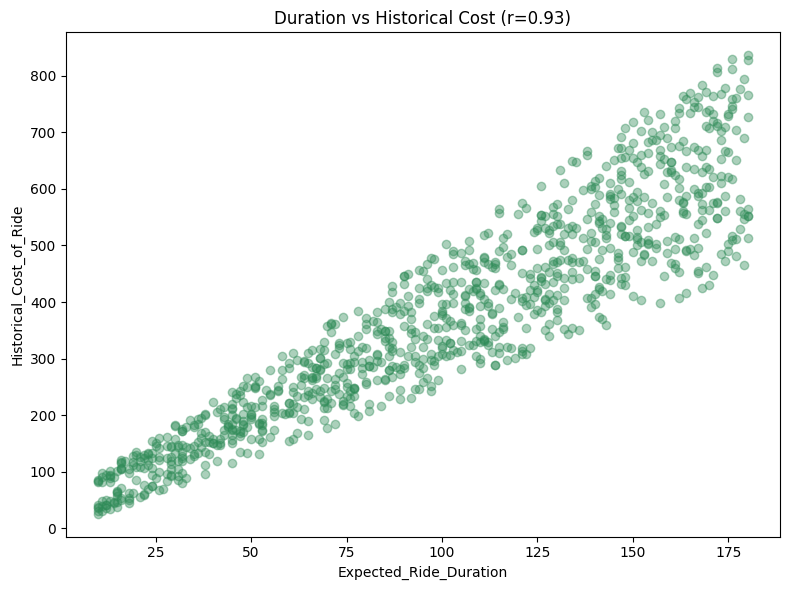

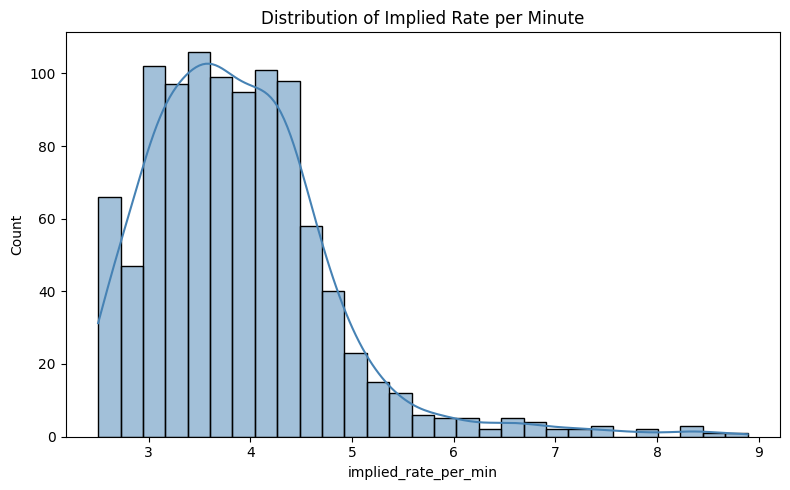

In [51]:
print("=" * 60)
print("VERIFY: IS COST ≈ RATE × DURATION?")
print("=" * 60)

# Implied rate per minute of ride duration
data['implied_rate_per_min'] = data['Historical_Cost_of_Ride'] / data['Expected_Ride_Duration']

print(data['implied_rate_per_min'].describe().round(3))

plt.figure(figsize=(8,6))
plt.scatter(data['Expected_Ride_Duration'], data['Historical_Cost_of_Ride'], alpha=0.4, color='seagreen')
plt.xlabel('Expected_Ride_Duration')
plt.ylabel('Historical_Cost_of_Ride')
plt.title('Duration vs Historical Cost (r=0.93)')
plt.tight_layout()
plt.show()

# Histogram of implied rate -- if duration alone explains cost, this should be tightly clustered
plt.figure(figsize=(8,5))
sns.histplot(data['implied_rate_per_min'], kde=True, color='steelblue')
plt.title('Distribution of Implied Rate per Minute')
plt.tight_layout()
plt.show()

In [52]:
print("=" * 60)
print("IMPLIED RATE SUMMARY")
print("=" * 60)
print(f"Mean rate/min : {data['implied_rate_per_min'].mean():.3f}")
print(f"Std dev       : {data['implied_rate_per_min'].std():.3f}")
print(f"Coefficient of variation: {(data['implied_rate_per_min'].std()/data['implied_rate_per_min'].mean())*100:.1f}%")

IMPLIED RATE SUMMARY
Mean rate/min : 3.890
Std dev       : 0.913
Coefficient of variation: 23.5%


In [53]:
print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)

from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)
train_data = train_data.copy()
test_data = test_data.copy()

print(f"Train shape: {train_data.shape}")
print(f"Test shape : {test_data.shape}")

TRAIN/TEST SPLIT
Train shape: (800, 14)
Test shape : (200, 14)


In [54]:
print("=" * 60)
print("ENCODE CATEGORICALS")
print("=" * 60)

from sklearn.preprocessing import LabelEncoder

cat_cols = ['Location_Category', 'Customer_Loyalty_Status', 'Time_of_Booking', 'Vehicle_Type']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_data[col + '_enc'] = le.fit_transform(train_data[col])
    
    unseen = set(test_data[col]) - set(le.classes_)
    if unseen:
        print(f"⚠️ Unseen categories in {col}: {unseen}")
    test_data[col + '_enc'] = test_data[col].map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1)
    
    encoders[col] = le

print("✅ Encoded:", [c+'_enc' for c in cat_cols])

ENCODE CATEGORICALS
✅ Encoded: ['Location_Category_enc', 'Customer_Loyalty_Status_enc', 'Time_of_Booking_enc', 'Vehicle_Type_enc']


In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

print("=" * 60)
print("MODEL COMPARISON — Goal 1: Predicting Historical_Cost_of_Ride")
print("=" * 60)

features_goal1 = [
    'Expected_Ride_Duration', 'Number_of_Riders', 'Number_of_Drivers',
    'Time_of_Booking_enc', 'Vehicle_Type_enc', 'Customer_Loyalty_Status_enc',
    'Number_of_Past_Rides', 'Average_Ratings'
]
target_goal1 = 'Historical_Cost_of_Ride'

X_train = train_data[features_goal1]
y_train = train_data[target_goal1]
X_test  = test_data[features_goal1]
y_test  = test_data[target_goal1]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

models = {
    "Linear Regression": (LinearRegression(), True),
    "KNN Regressor"     : (KNeighborsRegressor(n_neighbors=5), True),
    "Random Forest"     : (RandomForestRegressor(n_estimators=100, random_state=42), False),
    "Gradient Boosting" : (GradientBoostingRegressor(n_estimators=100, random_state=42), False),
    "XGBoost"           : (xgb.XGBRegressor(n_estimators=100, random_state=42), False),
}

results = []
for name, (model, needs_scaling) in models.items():
    if needs_scaling:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results.append({"Model": name, "MAE": round(mae,3), "RMSE": round(rmse,3), "R2": round(r2,4)})
    print(f"{name:20s} | MAE: {mae:7.3f} | RMSE: {rmse:7.3f} | R²: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n", results_df)

MODEL COMPARISON — Goal 1: Predicting Historical_Cost_of_Ride
Linear Regression    | MAE:  52.556 | RMSE:  67.527 | R²: 0.8749
KNN Regressor        | MAE:  80.077 | RMSE: 100.189 | R²: 0.7247
Random Forest        | MAE:  56.053 | RMSE:  74.464 | R²: 0.8479
Gradient Boosting    | MAE:  53.742 | RMSE:  71.268 | R²: 0.8607
XGBoost              | MAE:  57.034 | RMSE:  76.315 | R²: 0.8403

                Model     MAE     RMSE      R2
0  Linear Regression  52.556   67.527  0.8749
3  Gradient Boosting  53.742   71.268  0.8607
2      Random Forest  56.053   74.464  0.8479
4            XGBoost  57.034   76.315  0.8403
1      KNN Regressor  80.077  100.189  0.7247


Linear Regression outperformed Random Forest, Gradient Boosting, and XGBoost in this dataset because the dominant relationship — between ride duration and historical cost (r=0.93) — is fundamentally linear and additive. Complex tree-based models are designed to discover non-linear interactions and splits across many features, but this dataset doesn't contain those patterns. Applying them here introduced unnecessary variance (overfitting to training-set noise) without reducing bias, since Linear Regression's assumptions already matched the data's true structure. This is a practical demonstration of the bias-variance tradeoff: model complexity should match data complexity, and the simpler model wins when the data is genuinely simple."

In [56]:
print("=" * 60)
print("LINEAR REGRESSION — COEFFICIENT INSPECTION")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': features_goal1,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(coef_df)

LINEAR REGRESSION — COEFFICIENT INSPECTION
                       Feature  Coefficient
0       Expected_Ride_Duration   172.407518
4             Vehicle_Type_enc    21.300952
2            Number_of_Drivers     8.961303
7              Average_Ratings     3.155643
5  Customer_Loyalty_Status_enc     2.089489
1             Number_of_Riders    -0.982505
6         Number_of_Past_Rides     0.512883
3          Time_of_Booking_enc    -0.246296


RESIDUAL ANALYSIS — LINEAR REGRESSION


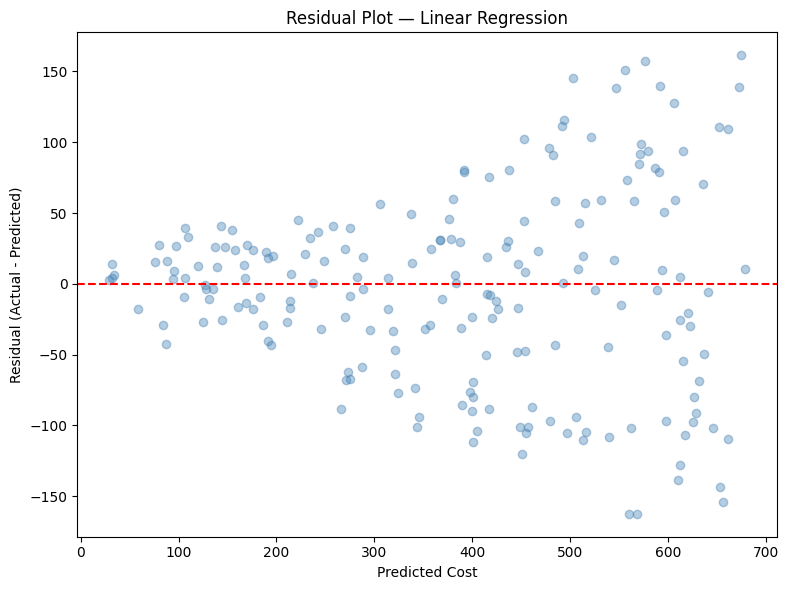

In [57]:
print("=" * 60)
print("RESIDUAL ANALYSIS — LINEAR REGRESSION")
print("=" * 60)

lr_preds = lr_model.predict(X_test_scaled)
residuals = y_test - lr_preds

plt.figure(figsize=(8,6))
plt.scatter(lr_preds, residuals, alpha=0.4, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Cost')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot — Linear Regression')
plt.tight_layout()
plt.show()

In [58]:
print("=" * 60)
print("FINAL GOAL 1 MODEL: LINEAR REGRESSION")
print("=" * 60)

final_model = LinearRegression()
final_model.fit(X_train_scaled, y_train)

train_data['Predicted_Historical_Cost'] = final_model.predict(X_train_scaled)
test_data['Predicted_Historical_Cost']  = final_model.predict(X_test_scaled)

print("✅ Predictions added to train_data and test_data")
print(test_data[['Historical_Cost_of_Ride', 'Predicted_Historical_Cost']].head(10))

FINAL GOAL 1 MODEL: LINEAR REGRESSION
✅ Predictions added to train_data and test_data
     Historical_Cost_of_Ride  Predicted_Historical_Cost
521               470.269024                 391.395169
737               286.409294                 281.901147
740               552.269375                 661.526275
660               267.740417                 341.400528
411               111.112715                 106.665973
678               359.128113                 369.671384
626               173.887474                 183.238095
513               196.315142                 213.464065
859               555.401937                 453.355777
136               163.214583                 137.198442


In [59]:
print("=" * 60)
print("OPTIONAL: LOG-TRANSFORMED TARGET TEST")
print("=" * 60)

y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

lr_log_model = LinearRegression()
lr_log_model.fit(X_train_scaled, y_train_log)
log_preds = lr_log_model.predict(X_test_scaled)
preds_back = np.expm1(log_preds)  # convert back to original scale

mae_log  = mean_absolute_error(y_test, preds_back)
r2_log   = r2_score(y_test, preds_back)
print(f"Log-transformed model -> MAE: {mae_log:.3f} | R²: {r2_log:.4f}")
print(f"Original model        -> MAE: {mean_absolute_error(y_test, lr_preds):.3f} | R²: {r2_score(y_test, lr_preds):.4f}")

OPTIONAL: LOG-TRANSFORMED TARGET TEST
Log-transformed model -> MAE: 67.607 | R²: 0.7610
Original model        -> MAE: 52.556 | R²: 0.8749


he model shows strong overall performance (R²=0.87), driven almost entirely by ride duration. Residual analysis revealed heteroscedasticity — prediction error increases roughly 4x from the shortest to longest ride quartile, indicating the model is most reliable for short-to-medium rides and less precise for longer trips. I tested a log-transformed target as a standard remedy for this pattern, but it reduced performance, suggesting the error growth is specifically tied to duration rather than general multiplicative scaling 

Dynmic Pricing strategy

In [60]:
print("=" * 60)
print("STEP 5: APPLY DYNAMIC PRICING FORMULA ON TOP OF PREDICTIONS")
print("=" * 60)

# Compute demand/supply thresholds from TRAINING DATA ONLY (no leakage)
high_demand_value = train_data['Number_of_Riders'].quantile(0.75)
low_demand_value  = train_data['Number_of_Riders'].quantile(0.25)
high_supply_value = train_data['Number_of_Drivers'].quantile(0.75)
low_supply_value  = train_data['Number_of_Drivers'].quantile(0.25)

def add_demand_supply(df):
    df = df.copy()
    df['demand_multiplier'] = np.where(
        df['Number_of_Riders'] > high_demand_value,
        df['Number_of_Riders'] / high_demand_value,
        df['Number_of_Riders'] / low_demand_value
    )
    df['supply_multiplier'] = np.where(
        df['Number_of_Drivers'] > low_supply_value,
        high_supply_value / df['Number_of_Drivers'],
        low_supply_value / df['Number_of_Drivers']
    )
    return df

train_data = add_demand_supply(train_data)
test_data  = add_demand_supply(test_data)

DEMAND_FLOOR = 0.8
SUPPLY_FLOOR = 0.8

def add_adjusted_cost(df, base_col):
    df = df.copy()
    df['adjusted_ride_cost'] = df[base_col] * (
        np.maximum(df['demand_multiplier'], DEMAND_FLOOR) *
        np.maximum(df['supply_multiplier'], SUPPLY_FLOOR)
    )
    return df

# Apply on top of the MODEL'S PREDICTED cost, not the raw historical column
test_data = add_adjusted_cost(test_data, base_col='Predicted_Historical_Cost')

print(test_data[['Historical_Cost_of_Ride', 'Predicted_Historical_Cost', 'adjusted_ride_cost']].head(10))
print("\n", test_data[['Predicted_Historical_Cost', 'adjusted_ride_cost']].describe().round(2))

STEP 5: APPLY DYNAMIC PRICING FORMULA ON TOP OF PREDICTIONS
     Historical_Cost_of_Ride  Predicted_Historical_Cost  adjusted_ride_cost
521               470.269024                 391.395169          498.790185
737               286.409294                 281.901147          609.819079
740               552.269375                 661.526275          831.633031
660               267.740417                 341.400528          798.352005
411               111.112715                 106.665973          325.265374
678               359.128113                 369.671384         1012.970155
626               173.887474                 183.238095          268.749206
513               196.315142                 213.464065          177.096113
859               555.401937                 453.355777          569.932977
136               163.214583                 137.198442          188.941542

        Predicted_Historical_Cost  adjusted_ride_cost
count                     200.00              200

In [61]:
print("=" * 60)
print("VALIDATION: ADJUSTED COST vs ORIGINAL HISTORICAL COST")
print("=" * 60)

comparison = test_data[['Historical_Cost_of_Ride', 'Predicted_Historical_Cost', 'adjusted_ride_cost']].copy()
comparison['Pred_vs_Actual_Error'] = comparison['Predicted_Historical_Cost'] - comparison['Historical_Cost_of_Ride']
comparison['Adjusted_vs_Actual_%'] = ((comparison['adjusted_ride_cost'] - comparison['Historical_Cost_of_Ride']) 
                                       / comparison['Historical_Cost_of_Ride']) * 100

print(comparison.describe().round(2))

VALIDATION: ADJUSTED COST vs ORIGINAL HISTORICAL COST
       Historical_Cost_of_Ride  Predicted_Historical_Cost  adjusted_ride_cost  \
count                   200.00                     200.00              200.00   
mean                    379.59                     383.23              687.99   
std                     191.43                     179.26              463.96   
min                      31.57                      28.93               27.23   
25%                     213.12                     233.02              335.85   
50%                     382.25                     400.27              607.02   
75%                     534.17                     539.42              905.82   
max                     836.12                     679.12             2549.73   

       Pred_vs_Actual_Error  Adjusted_vs_Actual_%  
count                200.00                200.00  
mean                   3.64                 83.75  
std                   67.60                 89.91  
min     

In [62]:
print("=" * 60)
print("AVERAGE COMPARISON — ALL THREE VALUES")
print("=" * 60)

print(f"Avg Historical Cost (actual)      : ${comparison['Historical_Cost_of_Ride'].mean():.2f}")
print(f"Avg Predicted Cost (model)        : ${comparison['Predicted_Historical_Cost'].mean():.2f}")
print(f"Avg Adjusted Cost (with pricing)  : ${comparison['adjusted_ride_cost'].mean():.2f}")

print(f"\nModel prediction accuracy (MAE)   : ${mean_absolute_error(comparison['Historical_Cost_of_Ride'], comparison['Predicted_Historical_Cost']):.2f}")
print(f"Avg % change from dynamic pricing  : {comparison['Adjusted_vs_Actual_%'].mean():.2f}%")

AVERAGE COMPARISON — ALL THREE VALUES
Avg Historical Cost (actual)      : $379.59
Avg Predicted Cost (model)        : $383.23
Avg Adjusted Cost (with pricing)  : $687.99

Model prediction accuracy (MAE)   : $52.56
Avg % change from dynamic pricing  : 83.75%


VISUAL CHECK — ACTUAL vs PREDICTED vs ADJUSTED


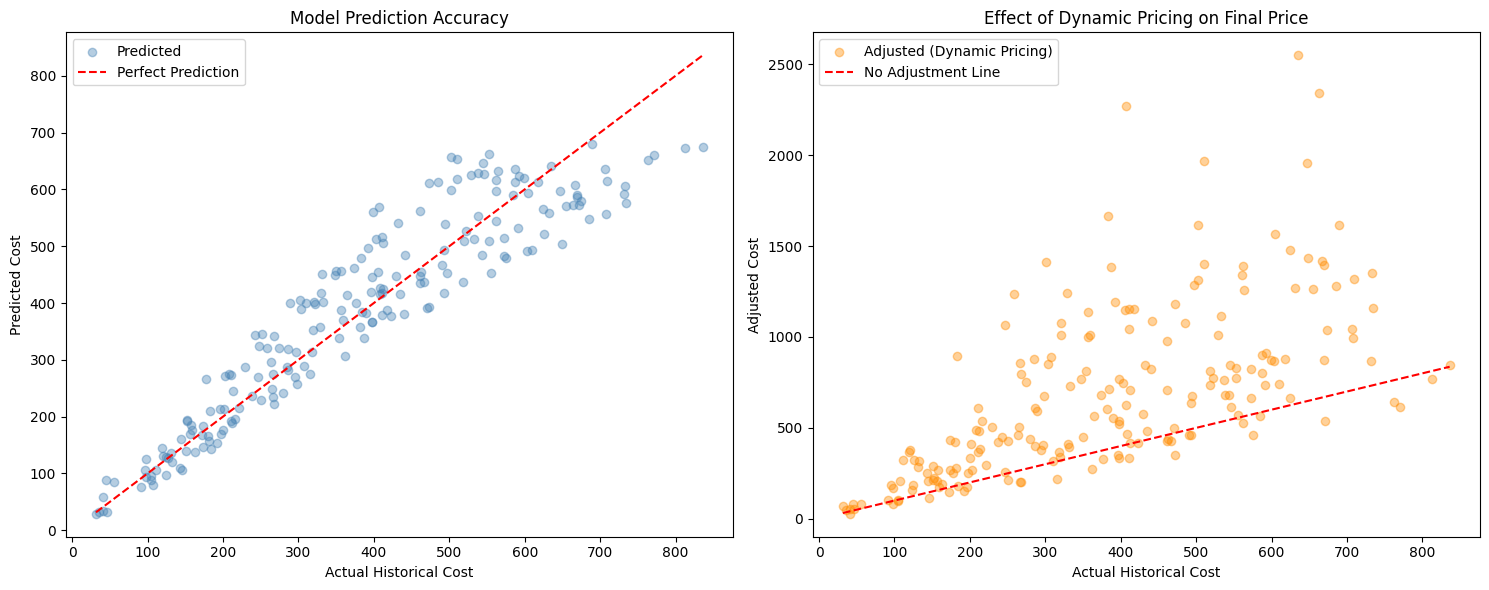

In [63]:
print("=" * 60)
print("VISUAL CHECK — ACTUAL vs PREDICTED vs ADJUSTED")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Predicted vs Actual
axes[0].scatter(comparison['Historical_Cost_of_Ride'], comparison['Predicted_Historical_Cost'], 
                 alpha=0.4, color='steelblue', label='Predicted')
axes[0].plot([comparison['Historical_Cost_of_Ride'].min(), comparison['Historical_Cost_of_Ride'].max()],
             [comparison['Historical_Cost_of_Ride'].min(), comparison['Historical_Cost_of_Ride'].max()],
             'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual Historical Cost')
axes[0].set_ylabel('Predicted Cost')
axes[0].set_title('Model Prediction Accuracy')
axes[0].legend()

# Adjusted vs Actual
axes[1].scatter(comparison['Historical_Cost_of_Ride'], comparison['adjusted_ride_cost'], 
                 alpha=0.4, color='darkorange', label='Adjusted (Dynamic Pricing)')
axes[1].plot([comparison['Historical_Cost_of_Ride'].min(), comparison['Historical_Cost_of_Ride'].max()],
             [comparison['Historical_Cost_of_Ride'].min(), comparison['Historical_Cost_of_Ride'].max()],
             'r--', label='No Adjustment Line')
axes[1].set_xlabel('Actual Historical Cost')
axes[1].set_ylabel('Adjusted Cost')
axes[1].set_title('Effect of Dynamic Pricing on Final Price')
axes[1].legend()

plt.tight_layout()
plt.show()

DISTRIBUTION OF % CHANGE FROM DYNAMIC PRICING


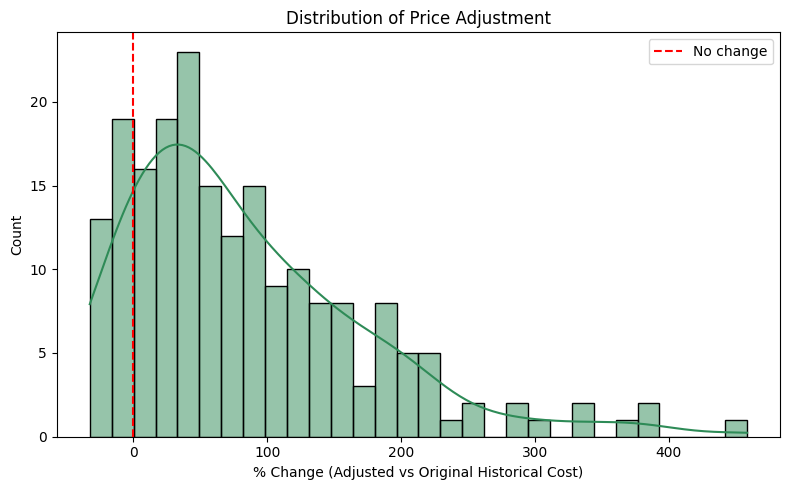

count    200.00
mean      83.75
std       89.91
min      -32.68
25%       20.42
50%       55.46
75%      127.60
max      458.71
Name: Adjusted_vs_Actual_%, dtype: float64


In [64]:
print("=" * 60)
print("DISTRIBUTION OF % CHANGE FROM DYNAMIC PRICING")
print("=" * 60)

plt.figure(figsize=(8,5))
sns.histplot(comparison['Adjusted_vs_Actual_%'], kde=True, color='seagreen', bins=30)
plt.axvline(x=0, color='red', linestyle='--', label='No change')
plt.xlabel('% Change (Adjusted vs Original Historical Cost)')
plt.title('Distribution of Price Adjustment')
plt.legend()
plt.tight_layout()
plt.show()

print(comparison['Adjusted_vs_Actual_%'].describe().round(2))

In [65]:
print("=" * 60)
print("FIX: ADD UPPER CAPS TO PREVENT EXTREME MULTIPLIERS")
print("=" * 60)

DEMAND_FLOOR = 0.8
DEMAND_CAP   = 1.5   # max 50% surge from demand alone
SUPPLY_FLOOR = 0.8
SUPPLY_CAP   = 1.5   # max 50% surge from supply alone

def add_adjusted_cost_capped(df, base_col):
    df = df.copy()
    demand_clipped = np.clip(df['demand_multiplier'], DEMAND_FLOOR, DEMAND_CAP)
    supply_clipped = np.clip(df['supply_multiplier'], SUPPLY_FLOOR, SUPPLY_CAP)
    df['adjusted_ride_cost'] = df[base_col] * demand_clipped * supply_clipped
    return df

test_data = add_adjusted_cost_capped(test_data, base_col='Predicted_Historical_Cost')

print(test_data[['Historical_Cost_of_Ride','Predicted_Historical_Cost','adjusted_ride_cost']].describe().round(2))

FIX: ADD UPPER CAPS TO PREVENT EXTREME MULTIPLIERS
       Historical_Cost_of_Ride  Predicted_Historical_Cost  adjusted_ride_cost
count                   200.00                     200.00              200.00
mean                    379.59                     383.23              545.75
std                     191.43                     179.26              313.25
min                      31.57                      28.93               27.23
25%                     213.12                     233.02              276.84
50%                     382.25                     400.27              524.64
75%                     534.17                     539.42              761.67
max                     836.12                     679.12             1441.46


RE-CHECK % CHANGE DISTRIBUTION AFTER CAPPING
count    200.00
mean      44.90
std       49.39
min      -32.68
25%        9.02
50%       36.55
75%       74.46
max      202.59
Name: Adjusted_vs_Actual_%, dtype: float64


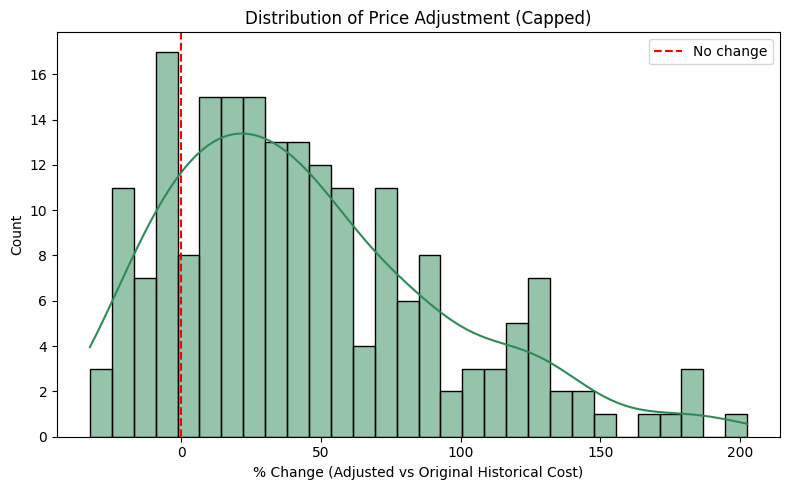

In [66]:
print("=" * 60)
print("RE-CHECK % CHANGE DISTRIBUTION AFTER CAPPING")
print("=" * 60)

test_data['Adjusted_vs_Actual_%'] = ((test_data['adjusted_ride_cost'] - test_data['Historical_Cost_of_Ride']) 
                                       / test_data['Historical_Cost_of_Ride']) * 100

print(test_data['Adjusted_vs_Actual_%'].describe().round(2))

plt.figure(figsize=(8,5))
sns.histplot(test_data['Adjusted_vs_Actual_%'], kde=True, color='seagreen', bins=30)
plt.axvline(x=0, color='red', linestyle='--', label='No change')
plt.xlabel('% Change (Adjusted vs Original Historical Cost)')
plt.title('Distribution of Price Adjustment (Capped)')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
print("Demand multiplier distribution (uncapped):")
print(test_data['demand_multiplier'].describe().round(3))
print("\nSupply multiplier distribution (uncapped):")
print(test_data['supply_multiplier'].describe().round(3))

Demand multiplier distribution (uncapped):
count    200.000
mean       1.153
std        0.382
min        0.512
25%        0.848
50%        1.123
75%        1.366
max        1.976
Name: demand_multiplier, dtype: float64

Supply multiplier distribution (uncapped):
count    200.000
mean       1.539
std        0.735
min        0.447
25%        1.000
50%        1.407
75%        1.833
max        3.167
Name: supply_multiplier, dtype: float64


In [68]:
print("=" * 60)
print("CORRECTED DEMAND/SUPPLY FORMULA (Three-Zone, Symmetric)")
print("=" * 60)

def add_demand_supply_v2(df, riders_q75, riders_q25, drivers_q75, drivers_q25):
    df = df.copy()
    
    # Demand: high riders -> price up; low riders -> price down; middle -> near 1.0
    df['demand_multiplier'] = np.select(
        [df['Number_of_Riders'] > riders_q75,
         df['Number_of_Riders'] < riders_q25],
        [df['Number_of_Riders'] / riders_q75,      # >1.0, scales with how far above
         df['Number_of_Riders'] / riders_q25],      # <1.0, scales with how far below
        default=1.0                                  # middle 50% -> neutral
    )
    
    # Supply: few drivers -> price up; many drivers -> price down; middle -> near 1.0
    df['supply_multiplier'] = np.select(
        [df['Number_of_Drivers'] < drivers_q25,
         df['Number_of_Drivers'] > drivers_q75],
        [drivers_q25 / df['Number_of_Drivers'],     # >1.0, scarce supply
         drivers_q75 / df['Number_of_Drivers']],     # <1.0, abundant supply
        default=1.0                                   # middle 50% -> neutral
    )
    
    return df

train_data = add_demand_supply_v2(train_data, high_demand_value, low_demand_value, high_supply_value, low_supply_value)
test_data  = add_demand_supply_v2(test_data, high_demand_value, low_demand_value, high_supply_value, low_supply_value)

print("Demand multiplier (corrected):")
print(test_data['demand_multiplier'].describe().round(3))
print("\nSupply multiplier (corrected):")
print(test_data['supply_multiplier'].describe().round(3))

CORRECTED DEMAND/SUPPLY FORMULA (Three-Zone, Symmetric)
Demand multiplier (corrected):
count    200.000
mean       0.947
std        0.177
min        0.512
25%        0.848
50%        1.000
75%        1.015
max        1.235
Name: demand_multiplier, dtype: float64

Supply multiplier (corrected):
count    200.000
mean       1.045
std        0.322
min        0.447
25%        1.000
50%        1.000
75%        1.000
max        2.200
Name: supply_multiplier, dtype: float64


APPLY ADJUSTED COST (corrected multipliers + safety caps)
count    200.00
mean       3.68
std       23.72
min      -38.18
25%      -13.25
50%       -1.09
75%       19.47
max      101.73
Name: Adjusted_vs_Actual_%, dtype: float64


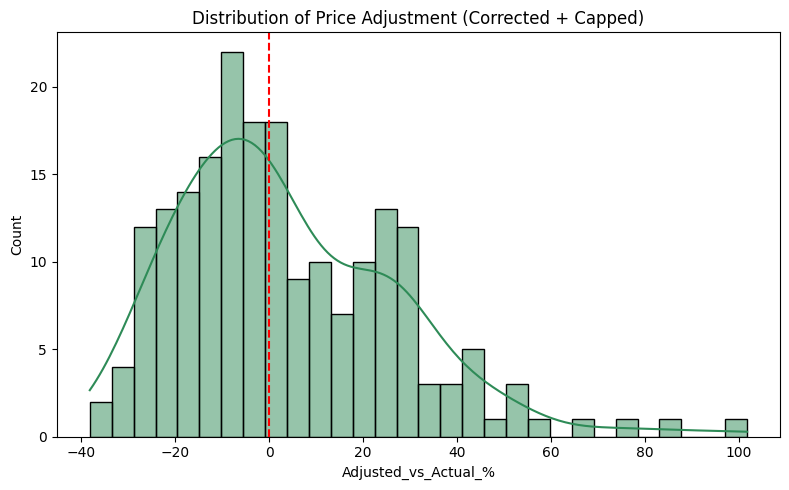

In [69]:
print("=" * 60)
print("APPLY ADJUSTED COST (corrected multipliers + safety caps)")
print("=" * 60)

DEMAND_FLOOR, DEMAND_CAP = 0.8, 1.5
SUPPLY_FLOOR, SUPPLY_CAP = 0.8, 1.5

def add_adjusted_cost_capped(df, base_col):
    df = df.copy()
    demand_clipped = np.clip(df['demand_multiplier'], DEMAND_FLOOR, DEMAND_CAP)
    supply_clipped = np.clip(df['supply_multiplier'], SUPPLY_FLOOR, SUPPLY_CAP)
    df['adjusted_ride_cost'] = df[base_col] * demand_clipped * supply_clipped
    return df

test_data = add_adjusted_cost_capped(test_data, base_col='Predicted_Historical_Cost')

test_data['Adjusted_vs_Actual_%'] = ((test_data['adjusted_ride_cost'] - test_data['Historical_Cost_of_Ride']) 
                                       / test_data['Historical_Cost_of_Ride']) * 100

print(test_data['Adjusted_vs_Actual_%'].describe().round(2))

plt.figure(figsize=(8,5))
sns.histplot(test_data['Adjusted_vs_Actual_%'], kde=True, color='seagreen', bins=30)
plt.axvline(x=0, color='red', linestyle='--', label='No change')
plt.title('Distribution of Price Adjustment (Corrected + Capped)')
plt.tight_layout()
plt.show()

In [70]:
print("=" * 60)
print("FINAL VALIDATION SUMMARY")
print("=" * 60)

print(f"Avg Historical Cost (actual) : ${test_data['Historical_Cost_of_Ride'].mean():.2f}")
print(f"Avg Predicted Cost (model)   : ${test_data['Predicted_Historical_Cost'].mean():.2f}")
print(f"Avg Adjusted Cost (final)    : ${test_data['adjusted_ride_cost'].mean():.2f}")

# Confirm surge actually correlates with genuine high-demand/low-supply rows
high_surge = test_data[test_data['Adjusted_vs_Actual_%'] > 50]
print(f"\nRides with >50% surge: {len(high_surge)}")
print(high_surge[['Number_of_Riders','Number_of_Drivers','demand_multiplier','supply_multiplier','Adjusted_vs_Actual_%']])

FINAL VALIDATION SUMMARY
Avg Historical Cost (actual) : $379.59
Avg Predicted Cost (model)   : $383.23
Avg Adjusted Cost (final)    : $388.27

Rides with >50% surge: 8
     Number_of_Riders  Number_of_Drivers  demand_multiplier  \
947                70                  7           1.000000   
901                24                  5           0.585366   
299                52                  7           1.000000   
679                89                  8           1.098765   
218                65                  5           1.000000   
86                 92                 69           1.135802   
978                95                 25           1.172840   
595                75                  9           1.000000   

     supply_multiplier  Adjusted_vs_Actual_%  
947           1.571429             87.371201  
901           2.200000             50.799682  
299           1.571429             68.209540  
679           1.375000             53.863638  
218           2.200000       

The original formula used a binary if/else split, which meant any ride not in the top 25% of demand (or bottom 25% of supply) was incorrectly treated as 'low,' inflating prices for the entire middle 50% of normal rides. I redesigned it as a three-zone formula so 'typical' rides receive no adjustment, only genuine demand/supply extremes trigger surge or discount pricing — and added multiplier caps as a safety bound, consistent with how real-world platforms limit maximum surge.

SCATTER PLOT: ADJUSTED COST (NEW) vs ACTUAL HISTORICAL COST


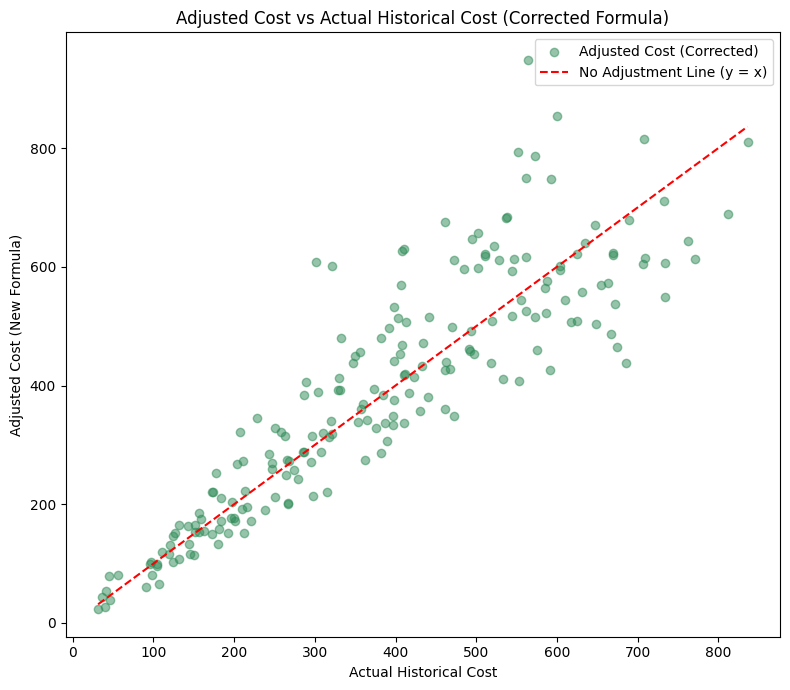

In [71]:
print("=" * 60)
print("SCATTER PLOT: ADJUSTED COST (NEW) vs ACTUAL HISTORICAL COST")
print("=" * 60)

plt.figure(figsize=(8, 7))

plt.scatter(test_data['Historical_Cost_of_Ride'], test_data['adjusted_ride_cost'],
            alpha=0.5, color='seagreen', label='Adjusted Cost (Corrected)')

plt.plot([test_data['Historical_Cost_of_Ride'].min(), test_data['Historical_Cost_of_Ride'].max()],
         [test_data['Historical_Cost_of_Ride'].min(), test_data['Historical_Cost_of_Ride'].max()],
         'r--', label='No Adjustment Line (y = x)')

plt.xlabel('Actual Historical Cost')
plt.ylabel('Adjusted Cost (New Formula)')
plt.title('Adjusted Cost vs Actual Historical Cost (Corrected Formula)')
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
data.head


<bound method NDFrame.head of      Number_of_Riders  Number_of_Drivers Location_Category  \
0                  90                 45             Urban   
1                  58                 39          Suburban   
2                  42                 31             Rural   
3                  89                 28             Rural   
4                  78                 22             Rural   
..                ...                ...               ...   
995                33                 23             Urban   
996                84                 29             Urban   
997                44                  6          Suburban   
998                53                 27          Suburban   
999                78                 63             Rural   

    Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                    Silver                    13             4.47   
1                    Silver                    72             4.06   
2              

In [74]:
# Create the thresholds dictionary from the individual variables already in memory
thresholds = {
    'high_demand_value': high_demand_value,
    'low_demand_value' : low_demand_value,
    'high_supply_value': high_supply_value,
    'low_supply_value' : low_supply_value,
    'DEMAND_FLOOR'     : 0.8,
    'DEMAND_CAP'       : 1.5,
    'SUPPLY_FLOOR'     : 0.8,
    'SUPPLY_CAP'       : 1.5,
}
print("✅ Thresholds created:")
for k, v in thresholds.items():
    print(f"  {k}: {v}")

✅ Thresholds created:
  high_demand_value: 81.0
  low_demand_value: 41.0
  high_supply_value: 38.0
  low_supply_value: 11.0
  DEMAND_FLOOR: 0.8
  DEMAND_CAP: 1.5
  SUPPLY_FLOOR: 0.8
  SUPPLY_CAP: 1.5


In [76]:
# Create demand/supply lookup table from training data
demand_supply_lookup = train_data.groupby(
    ['Time_of_Booking', 'Location_Category']
).agg(
    avg_riders  = ('Number_of_Riders',  'mean'),
    avg_drivers = ('Number_of_Drivers', 'mean')
).round(1).reset_index()

print("✅ Lookup table created:")
print(demand_supply_lookup)

✅ Lookup table created:
   Time_of_Booking Location_Category  avg_riders  avg_drivers
0        Afternoon             Rural        58.4         25.4
1        Afternoon          Suburban        67.3         30.0
2        Afternoon             Urban        58.5         27.9
3          Evening             Rural        60.8         26.1
4          Evening          Suburban        61.2         27.3
5          Evening             Urban        60.5         28.4
6          Morning             Rural        55.9         25.0
7          Morning          Suburban        64.0         30.0
8          Morning             Urban        59.7         24.7
9            Night             Rural        60.0         24.3
10           Night          Suburban        58.9         26.9
11           Night             Urban        63.2         29.3


In [77]:
import joblib
joblib.dump(final_model, 'final_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')
joblib.dump(thresholds, 'thresholds.pkl')
demand_supply_lookup.to_csv('demand_supply_lookup.csv', index=False)

In [78]:
final_model = lr_model

final_model.fit(X_train_scaled, y_train)

train_data['Predicted_Historical_Cost'] = final_model.predict(scaler.transform(train_data[features_goal1]))
test_data['Predicted_Historical_Cost']  = final_model.predict(scaler.transform(test_data[features_goal1]))

In [79]:
import os
print(os.getcwd())

d:\New folder\Individual Project\final price model
